# Pairs trading on the day lake — IV. Leaving pairs behind: the cross-section

## `pairs_trading_10_daily_cross_sectional.ipynb`

Notebook 08 screened 1.74 million pairs and found that, under false-discovery control, the median
formation yields **three** tradeable pairs out of 44,850 tested. Notebook 09 traded them and got a Sharpe
of 0.40 with a standard error of 0.26, on fewer than ten positions on average and roughly \$100k of
deployed capital.
The binding constraint was never the signal quality; it was **breadth**. Information ratio scales roughly
as signal quality times the square root of the number of independent bets, and a per-pair discovery
procedure that has to clear a multiple-testing correction cannot produce many bets.

This notebook removes that constraint by removing the discovery step. Instead of selecting pairs, it
holds a position in **every** eligible name every day, sized by how far that name's return has moved
relative to what its risk factors explain. Nothing is tested for significance, so nothing is lost to a
Benjamini–Hochberg threshold. This is the design behind Avellaneda & Lee (2010) and behind most
production equity statistical arbitrage.

The question is whether breadth alone buys a better result. The short answer is that it buys a genuine
edge for the first half of the sample and nothing at all for the second.

**Method.** Point-in-time universe of the 500 most traded eligible names (notebook 07's rules). Monthly
PCA on the trailing 252 sessions of returns gives 15 eigenportfolios as risk factors. Each day, every
name's trailing 60 sessions of returns are regressed on the factor returns; the signal is built from the
recent part of that history; the resulting weights are projected orthogonal to the factor loadings and
made dollar-neutral on a \$1M book. Everything uses trailing data only.

**Caching.** The two expensive passes are cached under `notebooks/cache/` (gitignored): about 11 minutes
cold on 16 cores, seconds warm.

## 0. Setup

In [1]:
from pathlib import Path
import os, re, sys, time, pickle, warnings

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pairs
from pairs import load_daily_bars, liquidity_screen

LAKE        = Path(os.environ.get("DAY_LAKE", Path.home() / "local/parquet_lake/day_adj"))
MARKET_ROOT = LAKE / "all_adjusted"
CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)

START, END  = "2004-01-01", "2025-08-13"
TRADE_START = "2006-01-01"                 # first 2 years feed the trailing windows
MIN_PRICE, MIN_DV, MIN_VOL, MAX_ABS_RET = 5.0, 20e6, 0.15, 1.0
UNIV_N, FORM_DAYS, N_FACTORS, REG_DAYS = 500, 252, 15, 60
CAP, COST_BPS = 1_000_000.0, 5.0

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 100})
Z = lambda a: (a - np.nanmean(a)) / (np.nanstd(a) + 1e-12)
print("pairs", pairs.__version__)

pairs 0.1.0


## 1. Data and the daily return panel

The same cached day-lake frame notebooks 07–09 use. Returns are total returns, with the dividend
recovered from the adjustment factors credited on its ex-date, winsorised at ±100% a day as a last
data-quality guard, and exchange test symbols dropped by name.

In [2]:
f_bars = CACHE / "day_market_bars.parquet"
if not f_bars.exists():
    load_daily_bars(None, START, END, MARKET_ROOT, with_dividends=True).to_parquet(f_bars)
bars = pd.read_parquet(f_bars)

px  = bars["close"].unstack("ticker")
div = bars["dividend"].unstack("ticker").reindex_like(px).fillna(0.0)
ret = ((px + div) / px.shift(1) - 1.0).clip(-1.0, 1.0)
TESTS = sorted(t for t in px.columns if re.fullmatch(r"Z[A-Z]ZZT", str(t)))
ret = ret.drop(columns=TESTS, errors="ignore")
sessions = ret.index
print(f"{ret.shape[1]:,} tickers x {ret.shape[0]:,} sessions, {sessions[0].date()} → {sessions[-1].date()}")
print(f"exchange test symbols dropped: {TESTS}")

33,303 tickers x 5,438 sessions, 2004-01-02 → 2025-08-13
exchange test symbols dropped: ['ZAZZT', 'ZBZZT', 'ZCZZT', 'ZDZZT', 'ZEZZT', 'ZFZZT', 'ZJZZT', 'ZOZZT', 'ZRZZT', 'ZUZZT', 'ZVZZT', 'ZWZZT', 'ZXZZT']


## 2. The engine

Three pieces, each a few lines.

**Universe.** Notebook 07's point-in-time screen, capped at the 500 most traded eligible names. Rebuilt
monthly, so a name that was liquid in 2008 and is gone today is in the 2008 book and not in the 2020 one.

**Factors.** PCA on the correlation matrix of the trailing 252 sessions of returns. Eigenvector
components are divided by each name's volatility, following Avellaneda–Lee, so an eigenportfolio is a
set of weights rather than a set of correlations. The top 15 are kept and their returns become the
factor returns.

**Residuals and weights.** Each day, every name's trailing 60 sessions are regressed on those factor
returns. A signal is formed from the recent residual (or raw) returns, the weight vector is projected
orthogonal to the loading matrix so the book carries no factor exposure, then centred to be
dollar-neutral and scaled to \$1M gross.

In [3]:
def universe_at(end, n=UNIV_N):
    start = end - pd.DateOffset(days=int(FORM_DAYS * 1.6))
    lvl = bars.index.get_level_values("datetime")
    w = bars[(lvl > start) & (lvl <= end)]
    st = liquidity_screen(w, min_price=MIN_PRICE, min_dollar_volume=MIN_DV, min_ann_vol=MIN_VOL,
                          max_abs_return=MAX_ABS_RET, exclude=TESTS, top_n=n)
    return list(st[st["eligible"]].index)

def eigenportfolios(R, k=N_FACTORS):
    # top-k eigenportfolio weights from the correlation matrix of a T x N return window
    sd = R.std(axis=0); ok = sd > 1e-12
    R, sd = R.loc[:, ok], sd[ok]
    C = np.nan_to_num(np.corrcoef(R.to_numpy(), rowvar=False), nan=0.0)
    vals, vecs = np.linalg.eigh(C)
    idx = np.argsort(vals)[::-1][:k]
    Q = vecs[:, idx] / sd.to_numpy()[:, None]            # weight by 1/sigma
    Q = Q / np.abs(Q).sum(axis=0, keepdims=True)         # unit gross per eigenportfolio
    return pd.DataFrame(Q, index=R.columns, columns=[f"f{i}" for i in range(len(idx))]), vals[idx] / vals.sum()

def neutralise(w, B):
    # project weights orthogonal to the factor loadings B (N x k), then dollar-neutralise and scale
    BtB = B.T @ B + 1e-8 * np.eye(B.shape[1])
    w = w - B @ np.linalg.solve(BtB, B.T @ w)
    w = w - w.mean()
    g = np.abs(w).sum()
    return w / g if g > 1e-12 else w

## 3. Does anything predict? Information coefficients, measured first

A trading rule cannot rescue a signal with no forecasting power, so the signals are scored before any
portfolio is built. For each probe day the factor model is fitted on trailing data only, several
candidate signals are formed, and each is correlated cross-sectionally against the **next day's** and
**next five days'** residual return. The average of those daily correlations is the information
coefficient.

Two of the candidates are the Avellaneda–Lee construction itself, and both disappoint.
Their s-score standardises the cumulative residual against an Ornstein–Uhlenbeck fit. Coded faithfully it
is degenerate: because the residual regression includes an intercept, the residuals sum to zero over the
window, so the cumulative process always ends at zero and the s-score reduces to a function of the fitted
mean alone. Their companion filter, which keeps only names whose estimated mean reversion is faster than
30 days, passes almost everything, because fitting an AR(1) to 60 points biases the autoregressive
coefficient downward. Both are reported below rather than quietly dropped.

In [4]:
def s_score_al(resid):
    # Avellaneda-Lee s-score and mean-reversion speed from the cumulative residual (W x N)
    X = np.cumsum(resid, axis=0)
    x0, x1 = X[:-1], X[1:]
    mx0, mx1 = x0.mean(0), x1.mean(0)
    cov = ((x0 - mx0) * (x1 - mx1)).sum(0); var = ((x0 - mx0) ** 2).sum(0)
    b = np.divide(cov, var, out=np.zeros_like(cov), where=var > 1e-18)
    a = mx1 - b * mx0
    zeta = x1 - (a + b * x0)
    var_z = (zeta ** 2).sum(0) / max(len(x0) - 2, 1)
    with np.errstate(divide="ignore", invalid="ignore"):
        kappa = -np.log(np.clip(b, 1e-9, 0.999999)) * 252.0
        m = a / (1.0 - b); sigma_eq = np.sqrt(var_z / (1.0 - b ** 2))
        s = (X[-1] - m) / sigma_eq
    bad = (b <= 0) | (b >= 1) | ~np.isfinite(s) | (sigma_eq <= 1e-12)
    return np.where(bad, np.nan, s), np.where(bad, np.nan, kappa)

def signals_from(R, resid, vol):
    return {
        "resid reversal 1d":    -Z(resid[-1]),
        "resid reversal 5d":    -Z(resid[-5:].sum(0)),
        "resid reversal 21d":   -Z(resid[-21:].sum(0)),
        "raw reversal 5d":      -Z(R[-5:].sum(0)),
        "raw reversal 5d skip1": -Z(R[-6:-1].sum(0)),
        "raw reversal 5d volwt": -Z(R[-5:].sum(0) / vol),
        "resid momentum 60d":   +Z(resid.sum(0)),
    }

def factor_day(i, Q, univ):
    # everything derived from the trailing window that ends the day before session i
    win = ret.iloc[i - REG_DAYS:i].reindex(columns=univ).dropna(axis=1)
    if win.shape[1] < 60:
        return None
    cols = win.columns
    Qw = Q.reindex(cols).to_numpy()
    R = win.to_numpy()
    F = R @ Qw
    Fm = np.column_stack([np.ones(len(F)), F])
    beta, *_ = np.linalg.lstsq(Fm, R, rcond=None)
    resid = R - Fm @ beta
    return dict(cols=cols, Qw=Qw, R=R, beta=beta, resid=resid, B=beta[1:].T,
                vol=resid.std(0) + 1e-6, r2=1.0 - resid.var(0) / (R.var(0) + 1e-18))

In [5]:
f_ic = CACHE / "xs_ic_panel.parquet"
if f_ic.exists():
    ic_panel = pd.read_parquet(f_ic)
else:
    recs, Q, univ, last, t0 = [], None, [], None, time.time()
    for d in sessions[(sessions >= TRADE_START) & (sessions <= END)][::5]:
        i = sessions.get_loc(d)
        if i < FORM_DAYS + REG_DAYS + 2 or i + 6 >= len(sessions): continue
        if last is None or (d - last).days > 25:
            univ = universe_at(d)
            hist = ret.iloc[i - FORM_DAYS:i].reindex(columns=univ).dropna(axis=1)
            if hist.shape[1] < 50: continue
            Q, _ = eigenportfolios(hist); univ = list(Q.index); last = d
        fd = factor_day(i, Q, univ)
        if fd is None: continue
        sig = signals_from(fd["R"], fd["resid"], fd["vol"])
        s_al, kappa = s_score_al(fd["resid"])
        sig["AL s-score"] = -s_al
        sig["AL kappa pass"] = (kappa > 252.0 / 30.0).astype(float)
        sig["factor R2"] = fd["r2"]
        for h, name in ((1, "fwd1"), (5, "fwd5")):
            fwd = ret.iloc[i:i + h].reindex(columns=fd["cols"]).to_numpy()
            sig[name] = (fwd - (fd["beta"][0] + (fwd @ fd["Qw"]) @ fd["beta"][1:])).sum(0)
        recs.append(pd.DataFrame(sig, index=fd["cols"]).assign(date=d))
    ic_panel = pd.concat(recs); ic_panel.to_parquet(f_ic)
    print(f"IC panel built in {time.time() - t0:.0f}s")

SIGNAL_COLS = ["raw reversal 5d", "raw reversal 5d skip1", "raw reversal 5d volwt",
               "resid reversal 1d", "resid reversal 5d", "resid reversal 21d",
               "resid momentum 60d", "AL s-score"]

def ic_table(fwd):
    out = []
    for c in SIGNAL_COLS:
        per_day = ic_panel.groupby("date").apply(
            lambda g: np.corrcoef(g[c], g[fwd])[0, 1] if g[c].notna().sum() > 30 else np.nan).dropna()
        a = per_day.to_numpy()
        out.append({"signal": c, "mean IC": a.mean(),
                    "t": a.mean() / a.std(ddof=1) * np.sqrt(len(a)), "share of days > 0": (a > 0).mean()})
    return pd.DataFrame(out).set_index("signal")

print(f"panel: {len(ic_panel):,} name-days over {ic_panel['date'].nunique()} probe days")
print(f"Avellaneda-Lee kappa filter passes {ic_panel['AL kappa pass'].mean():.0%} of names "
      f"— it is not filtering anything")
print(f"factor R^2: median {ic_panel['factor R2'].median():.2f}, "
      f"{np.mean(ic_panel['factor R2'] > 0.90):.0%} above 0.90 (index-like)")
ic1, ic5 = ic_table("fwd1"), ic_table("fwd5")
display(pd.concat({"next day": ic1, "next 5 days": ic5}, axis=1).round(4))

panel: 491,604 name-days over 986 probe days
Avellaneda-Lee kappa filter passes 99% of names — it is not filtering anything
factor R^2: median 0.70, 12% above 0.90 (index-like)


next day                            next 5 days  \
                       mean IC        t share of days > 0     mean IC   
signal                                                                  
raw reversal 5d         0.0333   8.5899            0.6508      0.0668   
raw reversal 5d skip1   0.0324   8.7510            0.6247      0.0636   
raw reversal 5d volwt   0.0249  12.6519            0.6725      0.0443   
resid reversal 1d       0.0088   2.3082            0.5412      0.0107   
resid reversal 5d       0.0092   2.4141            0.5358      0.0174   
resid reversal 21d      0.0052   1.4893            0.5358      0.0154   
resid momentum 60d     -0.0014  -0.4482            0.4761     -0.0009   
AL s-score              0.0091   3.9347            0.5574      0.0157   

                                                  
                             t share of days > 0  
signal                                            
raw reversal 5d        16.4551            0.7307  
raw reversal 5d skip1  16.0364            0.7293  
raw reversal 5d volwt  20.0047            0.7800  
resid reversal 1d       2.7134            0.5347  
resid reversal 5d       4.2604            0.5453  
resid reversal 21d      4.0007            0.5467  
resid momentum 60d     -0.2743            0.5067  
AL s-score              5.9492            0.5932

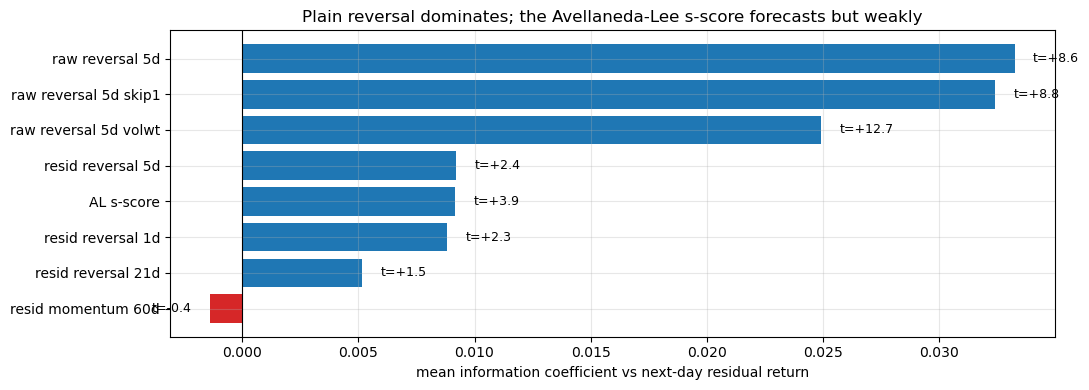

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
o = ic1.sort_values("mean IC")
ax.barh(range(len(o)), o["mean IC"], color=["tab:red" if v < 0 else "tab:blue" for v in o["mean IC"]])
for j, (v, t) in enumerate(zip(o["mean IC"], o["t"])):
    ax.text(v + (0.0008 if v >= 0 else -0.0008), j, f"t={t:+.1f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=9)
ax.set_yticks(range(len(o))); ax.set_yticklabels(o.index)
ax.axvline(0, color="k", lw=0.8); ax.set_xlabel("mean information coefficient vs next-day residual return")
ax.set_title("Plain reversal dominates; the Avellaneda-Lee s-score forecasts but weakly")
plt.tight_layout(); plt.show()

Two results, one expected and one not.

**Plain five-day reversal is the strongest signal by a wide margin.** Against the next day's residual
return its information coefficient is **+0.033 with t = 8.6**, positive on 65% of days; against the next
five days, **+0.067 with t = 16.5**, positive on 73%. Dividing by residual volatility trades a little
raw IC for a lot of consistency (0.025, but t = 12.7 and 67% of days). Residual reversal — the same idea
applied to the factor-stripped return — is real but four times weaker (0.009, t = 2.4). Residual
momentum over the full window forecasts nothing, which is what a 60-day horizon should do in a universe
of large caps.

**The Avellaneda–Lee s-score is not worthless, but it is dominated.** Its IC of 0.009 (t = 3.9) is in the
same class as residual reversal and far below plain reversal, and this is the version whose cumulative
process ends at zero by construction, so what is actually being measured is the shape of the residual
path rather than a deviation from equilibrium. The companion κ filter, meanwhile, passes **99%** of names
and therefore does no filtering at all: an AR(1) fitted to 60 observations has a downward-biased
autoregressive coefficient, so almost everything looks fast-mean-reverting. A faithful transcription of a
published method is not the same as a working one.

The rest of the notebook trades the reversal signals and ignores the s-score.

## 4. The portfolio

One pass builds the daily target weights for each surviving signal; evaluating a configuration
afterwards is cheap and reuses them. A configuration is a turnover damping factor (1.0 rebalances fully
to target each day, lower values move only part of the way) and a cost in basis points per side.

The book earns the **next** session's return on the weights set today, so nothing is forward-looking.

In [7]:
BUILD = ["raw reversal 5d", "raw reversal 5d skip1", "raw reversal 5d volwt",
         "resid reversal 5d", "resid reversal 21d"]

f_t = CACHE / "xs_targets.pkl"
if f_t.exists():
    targets, fwd_ret = pickle.load(open(f_t, "rb"))
else:
    targets = {s: {} for s in BUILD}; fwd_ret = {}
    Q, univ, last, t0 = None, [], None, time.time()
    for d in sessions[(sessions >= TRADE_START) & (sessions <= END)]:
        i = sessions.get_loc(d)
        if i < FORM_DAYS + REG_DAYS + 2 or i + 1 >= len(sessions): continue
        if last is None or (d - last).days > 25:
            univ = universe_at(d)
            hist = ret.iloc[i - FORM_DAYS:i].reindex(columns=univ).dropna(axis=1)
            if hist.shape[1] < 50: continue
            Q, _ = eigenportfolios(hist); univ = list(Q.index); last = d
        fd = factor_day(i, Q, univ)
        if fd is None: continue
        sig = signals_from(fd["R"], fd["resid"], fd["vol"])
        for s in BUILD:
            targets[s][d] = pd.Series(neutralise(np.nan_to_num(sig[s], nan=0.0), fd["B"]), index=fd["cols"])
        fwd_ret[d] = ret.iloc[i + 1].reindex(fd["cols"])
    pickle.dump((targets, fwd_ret), open(f_t, "wb"), protocol=5)
    print(f"targets built in {time.time() - t0:.0f}s")
print(f"{len(fwd_ret):,} trading sessions, {sorted(fwd_ret)[0].date()} → {sorted(fwd_ret)[-1].date()}")

4,933 trading sessions, 2006-01-03 → 2025-08-12


In [8]:
def run(tgt_by_day, blend=1.0, cost_bps=COST_BPS):
    w_prev, rows = pd.Series(dtype=float), []
    for d in sorted(tgt_by_day):
        t = tgt_by_day[d] * CAP
        idx = t.index.union(w_prev.index)
        t_al, p_al = t.reindex(idx).fillna(0.0), w_prev.reindex(idx).fillna(0.0)
        w = p_al + blend * (t_al - p_al)
        g = w.abs().sum()
        if g > 0: w = w * (CAP / g)
        traded = float((w - p_al).abs().sum())
        r = fwd_ret[d].reindex(w.index).fillna(0.0)
        gross = float((w * r).sum())
        rows.append({"date": d, "pnl_gross": gross, "cost": traded * cost_bps / 1e4,
                     "pnl": gross - traded * cost_bps / 1e4, "traded": traded,
                     "n": int((w.abs() > 1e-9).sum())})
        w_prev = w[w.abs() > 1e-9]
    return pd.DataFrame(rows).set_index("date")

sharpe = lambda x: x.mean() / x.std(ddof=0) * np.sqrt(252) if x.std(ddof=0) > 0 else np.nan

def summarize(d, label):
    eq = d["pnl"].cumsum()
    return {"config": label, "Sharpe net": sharpe(d["pnl"] / CAP), "Sharpe gross": sharpe(d["pnl_gross"] / CAP),
            "ann return": (d["pnl"] / CAP).mean() * 252, "ann vol": (d["pnl"] / CAP).std(ddof=0) * np.sqrt(252),
            "P&L ($k)": d["pnl"].sum() / 1e3, "costs ($k)": d["cost"].sum() / 1e3,
            "max DD ($k)": (eq - eq.cummax()).min() / 1e3, "names": d["n"].mean(),
            "daily turnover": d["traded"].mean() / CAP,
            "break-even bps": d["pnl_gross"].sum() / d["traded"].sum() * 1e4}

runs = {(s, b): run(targets[s], blend=b, cost_bps=COST_BPS) for s in BUILD for b in (1.0, 0.25)}
tab = pd.DataFrame([summarize(v, f"{s} | blend {b}") for (s, b), v in runs.items()]).set_index("config")
display(tab.round(3))

,Sharpe net,Sharpe gross,ann return,ann vol,P&L ($k),costs ($k),max DD ($k),names,daily turnover,break-even bps
config,,,,,,,,,,
raw reversal 5d | blend 1.0,-0.289,0.515,-0.029,0.100,-566.913,1578.320,-848.252,498.447,0.640,3.204
raw reversal 5d | blend 0.25,0.046,0.371,0.004,0.096,86.122,612.583,-502.485,563.692,0.248,5.703
raw reversal 5d skip1 | blend 1.0,-0.337,0.496,-0.033,0.097,-637.442,1576.943,-910.561,498.447,0.639,2.979
raw reversal 5d skip1 | blend 0.25,-0.049,0.289,-0.005,0.093,-88.097,612.309,-472.634,563.590,0.248,4.281
raw reversal 5d volwt | blend 1.0,-0.606,0.558,-0.042,0.069,-821.673,1576.963,-822.788,498.447,0.639,2.395
raw reversal 5d volwt | blend 0.25,-0.058,0.433,-0.004,0.064,-72.049,610.907,-255.253,566.566,0.248,4.410
resid reversal 5d | blend 1.0,-1.432,0.323,-0.067,0.047,-1304.090,1598.315,-1309.528,498.447,0.648,0.920
resid reversal 5d | blend 0.25,-0.272,0.433,-0.012,0.046,-243.599,630.677,-440.671,566.161,0.256,3.069
resid reversal 21d | blend 1.0,-0.925,0.150,-0.039,0.042,-757.588,880.110,-796.417,498.447,0.357,0.696


Every variant makes money before costs, and all but one loses it after. Gross Sharpe runs from 0.15 to
0.56; net of 5 bps a side the single survivor is plain five-day reversal damped to a quarter of the
distance to target, at 0.046, and the other nine are negative.

The reason is in the turnover column. For the five-day signals, rebalancing fully to target moves **64%
of the book every day**, which on a \$1M book over twenty years costs \$1.6M — more than the book itself.
Moving only 25% of the distance to target cuts turnover by 60% — not by 75%, because the target is
persistent from day to day — and actually *raises* net Sharpe for every signal, because the signal decays
slowly enough that most of that trading was noise. It is the clearest possible statement that this is a
cost problem rather than a signal problem.

## 5. Cost is the whole story

Turnover is enormous: rebalancing fully to target moves much of the book every day. The break-even cost
in the table above is the level at which the gross edge is exactly consumed. Sweeping the cost shows how
little room there is.

turnover  break-even bps  0 bps  1 bps  2 bps  \
signal                blend                                                  
raw reversal 5d       1.00      0.640           3.204  0.515  0.354  0.194   
                      0.25      0.248           5.703  0.371  0.306  0.241   
raw reversal 5d skip1 1.00      0.639           2.979  0.496  0.330  0.163   
                      0.25      0.248           4.281  0.289  0.222  0.154   
raw reversal 5d volwt 1.00      0.639           2.395  0.558  0.325  0.092   
                      0.25      0.248           4.410  0.433  0.335  0.237   
resid reversal 5d     1.00      0.648           0.920  0.323 -0.028 -0.379   
                      0.25      0.256           3.069  0.433  0.292  0.151   
resid reversal 21d    1.00      0.357           0.696  0.150 -0.065 -0.280   
                      0.25      0.145           1.956  0.178  0.087 -0.004   

                             3 bps  5 bps  10 bps  
signal                blend                        
raw reversal 5d       1.00   0.033 -0.289  -1.093  
                      0.25   0.176  0.046  -0.280  
raw reversal 5d skip1 1.00  -0.004 -0.337  -1.170  
                      0.25   0.087 -0.049  -0.387  
raw reversal 5d volwt 1.00  -0.141 -0.606  -1.769  
                      0.25   0.138 -0.058  -0.548  
resid reversal 5d     1.00  -0.730 -1.432  -3.187  
                      0.25   0.010 -0.272  -0.978  
resid reversal 21d    1.00  -0.495 -0.925  -1.999  
                      0.25  -0.095 -0.277  -0.732

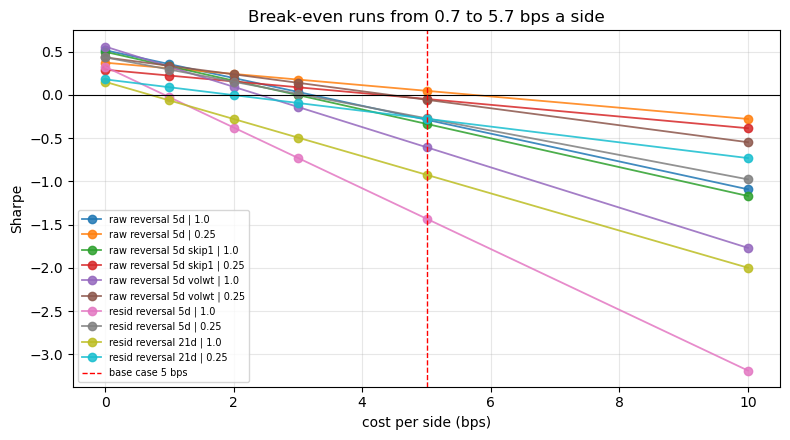

In [9]:
COSTS = [0.0, 1.0, 2.0, 3.0, 5.0, 10.0]
rows = []
for (s, b), base in runs.items():
    rec = {"signal": s, "blend": b, "turnover": base["traded"].mean() / CAP,
           "break-even bps": base["pnl_gross"].sum() / base["traded"].sum() * 1e4}
    for c in COSTS:
        rec[f"{c:g} bps"] = sharpe((base["pnl_gross"] - base["traded"] * c / 1e4) / CAP)
    rows.append(rec)
sweep = pd.DataFrame(rows).set_index(["signal", "blend"])
display(sweep.round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
for (s, b), base in runs.items():
    y = [sharpe((base["pnl_gross"] - base["traded"] * c / 1e4) / CAP) for c in COSTS]
    ax.plot(COSTS, y, marker="o", lw=1.3, alpha=0.85, label=f"{s} | {b}")
ax.axhline(0, color="k", lw=0.8); ax.axvline(COST_BPS, color="r", ls="--", lw=1, label="base case 5 bps")
ax.set_xlabel("cost per side (bps)"); ax.set_ylabel("Sharpe"); ax.legend(fontsize=7)
ax.set_title("Break-even runs from 0.7 to 5.7 bps a side")
plt.tight_layout(); plt.show()

The break-even costs are between 0.7 and 5.7 bps a side, and the best of them belongs to a damped
configuration. At 2 bps — achievable for a \$1M book in the 500 most traded US names with patient
execution — the *damped raw-reversal* variants deliver Sharpe ratios of 0.15 to 0.24. Rebalancing fully to
target gives 0.09 to 0.19 on the same signals, and the residual-reversal configurations are at or below
zero apart from one that also reaches 0.15. At the 5 bps used elsewhere in this
repository only one configuration is positive at all.

That is a narrow window, and it is the whole investment case. There is no configuration here whose edge
is large enough that the cost assumption stops mattering.

## 6. Is it bid-ask bounce?

Short-horizon reversal is the classic place to mistake microstructure for alpha. A stock that closed on
the bid looks like a loser and "reverts" when it next closes on the ask, and that reversion is not
tradeable. The break-even costs above sit close to the 3–4 bps effective spreads measured for these names
in notebook 11, which is exactly what a bounce-driven signal would look like.

The test is to skip the most recent session, forming the signal from returns over t−6 to t−2 instead of
t−5 to t−1. The bounce lives in the last close; a genuine multi-day over-reaction does not.

In [10]:
pairs_to_compare = [("raw reversal 5d", "raw reversal 5d skip1")]
rows = []
for a, b in pairs_to_compare:
    for blend in (1.0, 0.25):
        for name in (a, b):
            base = runs[(name, blend)]
            rows.append({"signal": name, "blend": blend,
                         "Sharpe gross": sharpe(base["pnl_gross"] / CAP),
                         "break-even bps": base["pnl_gross"].sum() / base["traded"].sum() * 1e4})
skip = pd.DataFrame(rows).set_index(["blend", "signal"]).sort_index()
display(skip.round(3))
g_full = sharpe(runs[("raw reversal 5d", 1.0)]["pnl_gross"] / CAP)
g_skip = sharpe(runs[("raw reversal 5d skip1", 1.0)]["pnl_gross"] / CAP)
print(f"gross Sharpe with the most recent session included {g_full:.3f}, excluded {g_skip:.3f} "
      f"({g_skip / g_full - 1:+.0%})")

Sharpe gross  break-even bps
blend signal                                             
0.25  raw reversal 5d               0.371           5.703
      raw reversal 5d skip1         0.289           4.281
1.00  raw reversal 5d               0.515           3.204
      raw reversal 5d skip1         0.496           2.979

gross Sharpe with the most recent session included 0.515, excluded 0.496 (-4%)


The signal survives. Dropping the most recent session costs only 4% of gross Sharpe, 0.515 against 0.496
at full rebalancing, and the break-even cost barely moves. If the edge were bid-ask bounce it would
collapse, because the bounce lives entirely in the last close.

So this is a genuine multi-day over-reaction in the idiosyncratic component, not a microstructure
artifact — which makes the coincidence between the break-even cost and the effective spread a coincidence
rather than a diagnosis. The signal is real. It is simply small enough that the spread is the right order
of magnitude to consume it.

## 7. When did it work?

The pairs book of notebook 09 earned more than half its twenty-year P&L in a single year. The right
question for this book is the same one: is the edge a stream or an episode?

date,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
gross,1.03,-0.90,1.59,0.98,0.83,0.89,0.21,0.41,0.96,0.79,0.60,-0.10,-0.53,0.02,-0.57,0.29,1.04,-0.13,0.19,0.24
net @2bps,0.62,-1.18,1.51,0.88,0.66,0.78,-0.05,0.08,0.72,0.61,0.45,-0.46,-0.69,-0.21,-0.62,0.09,0.92,-0.32,-0.03,0.13
net @5bps,-0.01,-1.61,1.40,0.73,0.41,0.61,-0.43,-0.41,0.37,0.34,0.21,-0.99,-0.94,-0.56,-0.70,-0.21,0.75,-0.60,-0.36,-0.03
gross P&L ($k),31.69,-39.25,268.88,124.03,61.64,100.08,10.08,15.84,50.94,55.38,48.36,-3.49,-39.72,1.11,-135.08,18.15,111.34,-8.52,10.73,16.51


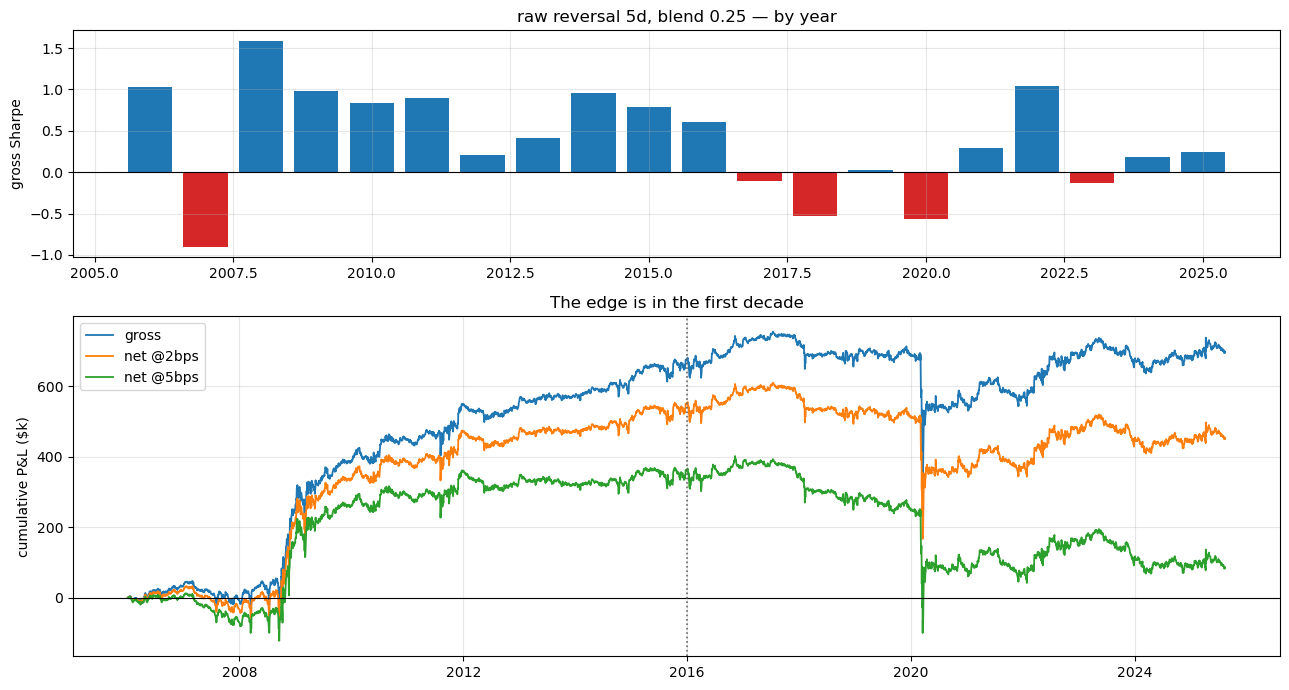

years with positive gross P&L: 15/20; largest single year is 38% of the total (notebook 09's pairs book: 52%)


In [11]:
BEST = ("raw reversal 5d", 0.25)
base = runs[BEST]
yr = pd.DataFrame({
    lbl: base.groupby(base.index.year).apply(
        lambda g: sharpe((g["pnl_gross"] - g["traded"] * c / 1e4) / CAP))
    for lbl, c in (("gross", 0.0), ("net @2bps", 2.0), ("net @5bps", 5.0))})
yr["gross P&L ($k)"] = base.groupby(base.index.year)["pnl_gross"].sum() / 1e3
display(yr.round(2).T)

fig, ax = plt.subplots(2, 1, figsize=(13, 7), height_ratios=[2, 3])
c = ["tab:blue" if v > 0 else "tab:red" for v in yr["gross"]]
ax[0].bar(yr.index, yr["gross"], color=c); ax[0].axhline(0, color="k", lw=0.8)
ax[0].set_ylabel("gross Sharpe"); ax[0].set_title(f"{BEST[0]}, blend {BEST[1]} — by year")
for lbl, cost in (("gross", 0.0), ("net @2bps", 2.0), ("net @5bps", 5.0)):
    eq = (base["pnl_gross"] - base["traded"] * cost / 1e4).cumsum() / 1e3
    ax[1].plot(eq.index, eq, lw=1.3, label=lbl)
ax[1].axhline(0, color="k", lw=0.8); ax[1].axvline(pd.Timestamp("2016-01-01"), color="0.4", ls=":", lw=1.2)
ax[1].set_ylabel("cumulative P&L ($k)"); ax[1].legend(); ax[1].set_title("The edge is in the first decade")
plt.tight_layout(); plt.show()

g = base.groupby(base.index.year)["pnl_gross"].sum()
print(f"years with positive gross P&L: {int((g > 0).sum())}/{len(g)}; "
      f"largest single year is {g.max() / g.sum():.0%} of the total (notebook 09's pairs book: 52%)")

In [12]:
split = []
for (s, b), base in runs.items():
    first, second = base[base.index < "2016-01-01"], base[base.index >= "2016-01-01"]
    row = {"signal": s, "blend": b}
    for lbl, d in (("2006-2015", first), ("2016-2025", second)):
        row[f"gross {lbl}"] = sharpe(d["pnl_gross"] / CAP)
        row[f"net@2bps {lbl}"] = sharpe((d["pnl_gross"] - d["traded"] * 2 / 1e4) / CAP)
    split.append(row)
split = pd.DataFrame(split).set_index(["signal", "blend"])
display(split.round(2))
n_decay = int((split["gross 2006-2015"] > split["gross 2016-2025"]).sum())
print(f"variants whose gross Sharpe is higher in the first decade: {n_decay}/{len(split)}")
print(f"mean gross Sharpe: {split['gross 2006-2015'].mean():.2f} in 2006-2015, "
      f"{split['gross 2016-2025'].mean():.2f} in 2016-2025")
print(f"standard error of a Sharpe over each half: {np.sqrt(252 / (len(base) / 2)):.2f}")

gross 2006-2015  net@2bps 2006-2015  \
signal                blend                                        
raw reversal 5d       1.00              0.85                0.52   
                      0.25              0.77                0.63   
raw reversal 5d skip1 1.00              0.95                0.60   
                      0.25              0.66                0.51   
raw reversal 5d volwt 1.00              0.81                0.37   
                      0.25              0.68                0.49   
resid reversal 5d     1.00              0.71               -0.01   
                      0.25              0.91                0.61   
resid reversal 21d    1.00              0.33               -0.14   
                      0.25              0.15               -0.05   

                             gross 2016-2025  net@2bps 2016-2025  
signal                blend                                       
raw reversal 5d       1.00              0.19               -0.12  
                      0.25              0.02               -0.10  
raw reversal 5d skip1 1.00              0.07               -0.25  
                      0.25             -0.03               -0.16  
raw reversal 5d volwt 1.00              0.26               -0.25  
                      0.25              0.14               -0.07  
resid reversal 5d     1.00             -0.06               -0.74  
                      0.25             -0.00               -0.27  
resid reversal 21d    1.00             -0.01               -0.41  
                      0.25              0.20                0.03

variants whose gross Sharpe is higher in the first decade: 9/10
mean gross Sharpe: 0.68 in 2006-2015, 0.08 in 2016-2025
standard error of a Sharpe over each half: 0.32


It is an episode, and a long one that ended.

Fifteen of twenty years have positive gross P&L, and the concentration is milder than the pairs book's:
the largest single year is 38% of the total against 52% for notebook 09. But the split is not random.
**Gross Sharpe is 0.77 over 2006–2015 and 0.02 over 2016–2025**, and at 2 bps the same halves give +0.63
and −0.10. Nine of the ten signal-and-damping variants show the same direction, with the mean gross
Sharpe falling from 0.68 to 0.08.

The standard error of a Sharpe over each half is 0.32, so the first-decade result is around two standard
errors from zero and the second is indistinguishable from it. The best years — 2008, 2009, 2011, 2022 —
are volatile ones, which is what a reversal strategy should prefer: over-reaction is largest when the
market is moving. But 2020, which contained the sample's most violent volatility spike, is the worst. Volatility is not
sufficient.

This is the crowding-out of short-term reversal that the literature has documented since the mid-2000s,
reproduced here on point-in-time data with survivorship bias and dividend look-ahead removed.

## 8. Honest assessment

**The breadth argument was right, and it was not enough.** Removing the discovery step removed the
multiple-testing bottleneck exactly as intended: this book holds about 500 positions every day against
the pairs book's ten or fewer, needs no significance threshold, and deploys ten times the capital. Its
gross edge is positive in 15 of 20 years and less concentrated than the pairs result. What it does not do
is earn more after costs. Over the full span the best net Sharpe at 5 bps is **0.05**, against **0.40**
for notebook 09's Benjamini–Hochberg pairs — and neither is distinguishable from zero.

**Breadth does not come free, because turnover scales with it.** A 500-name book rebalanced daily trades
15–65% of itself per session. The information ratio gained from more bets is handed straight back at the
spread. The binding constraint is not how many positions you hold but how much signal each unit of
turnover carries, and on that measure this strategy is weak: break-even between 0.7 and 5.7 bps a side.

**The signal is real and it decayed.** Five-day reversal forecasts next-day residual returns with t = 8.6
over 986 probe days, survives skipping the most recent session, and is therefore not a microstructure
artifact. It earned a gross Sharpe of 0.77 in 2006–2015 and 0.02 in 2016–2025, with nine of ten variants
agreeing. Anyone finding this effect on a sample ending before about 2015 and extrapolating would have
been badly wrong.

**Where this leaves the Sharpe question.** Three approaches have now been measured in this
repository: cointegrated pairs under FDR control on the point-in-time day lake (0.40 ± 0.26, but on
fewer than ten positions on average), the same pairs intraday (indistinguishable from zero, notebooks 11–13 — a
much shorter span on the minute lake's universe of *today's* index members, so that leg still carries
the survivorship bias this one removes), and the whole cross-section on the day lake
(0.05 net, real but dead since 2016). None reaches 1. The common thread is not that the signals are
absent — the ICs here are strongly significant — but that each is small relative to the cost of
harvesting it. Improving that ratio, through slower-decaying signals or sub-2 bps execution, is the only
lever that has not been tried.

**Caveats.** One universe and one market; a PCA factor model re-estimated monthly rather than daily; costs
are a flat per-side charge with no spread, impact or borrow modelling; the book is equal-gross rather than
risk-optimised; no shorting constraints or locate costs; and the signal menu was chosen by the author,
so the ICs in §3 carry a selection effect of their own even though none of the trading rules were tuned.